In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data/netflix_titles.csv')

# Basic exploration
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.isnull().sum())
print(df['type'].value_counts())  # Movies vs TV Shows
print(df['rating'].value_counts())  # Content ratings
print(df['country'].value_counts().head(10))  # Top countries
print(df.isnull().sum()
      )

(8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   dura

In [2]:
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

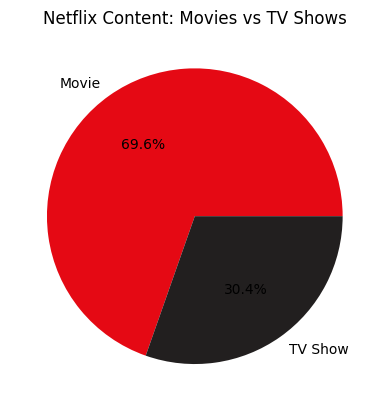

In [4]:
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',colors=['#E50914', '#221F1F'])
plt.title('Netflix Content: Movies vs TV Shows')
plt.savefig('charts/chart1_type_distribution.png')
plt.show()

C:\Users\karun\AppData\Local\Temp\ipykernel_22764\2489375584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


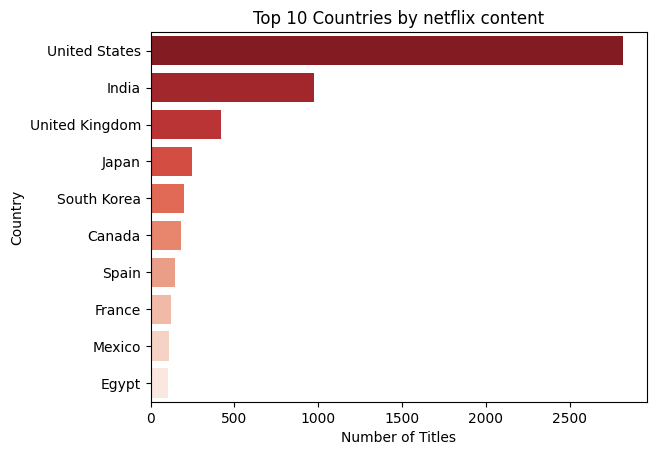

In [7]:
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Countries by netflix content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig('charts/chart2_top_countries.png')
plt.show()

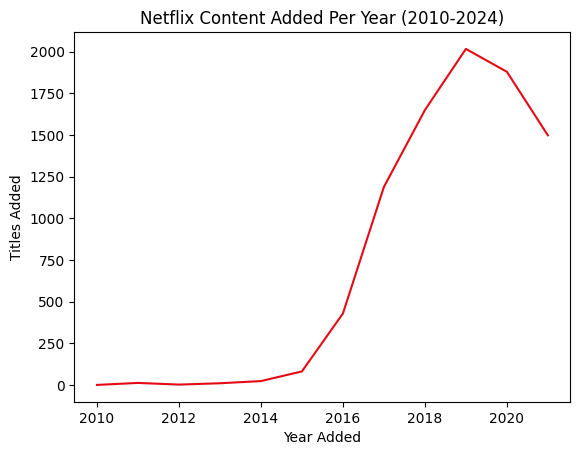

In [8]:
yearly = df['year_added'].value_counts().sort_index()
yearly = yearly[yearly.index >= 2010]
sns.lineplot(x=yearly.index, y=yearly.values,color='#E50914')
plt.title('Netflix Content Added Per Year (2010-2024)')
plt.xlabel('Year Added')
plt.ylabel('Titles Added')
plt.savefig('charts/chart3_yearly_growth.png')
plt.show()  

C:\Users\karun\AppData\Local\Temp\ipykernel_22764\3888884293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='Oranges_r')


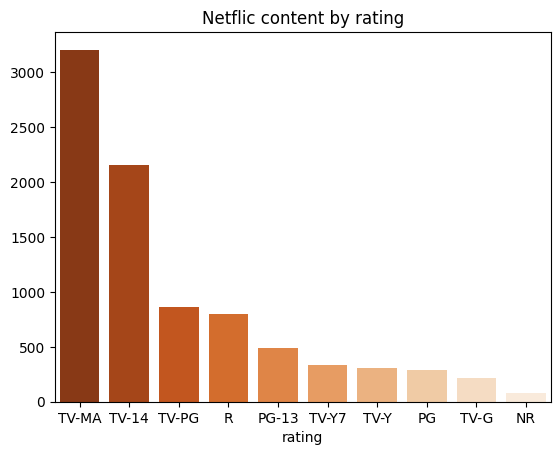

In [12]:
top_ratings = df['rating'].value_counts().head(10)
sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='Oranges_r')
plt.title('Netflic content by rating')
plt.savefig('charts/chart4_ratings.png')
plt.show()


In [ ]:
df['genre'] = df['listed_in'].str.split(',').str[0]
top_genres = df['genre'].value_counts().head(10)
sns.barplot(x=top_genres.index, y=top_genres.values, palette='Blues_r')
plt.title('Top 10 Genres on Netflix')
plt.savefig('charts/chart5_top_genres.png')
plt.show()

KeyError: 'listend_in'